# Hierarchical ARM V2 - Visualization Notebook

Notebook này dùng để visualization predictions của mô hình HierarchicalARM_V2:
- Stage 1: ROI Means predictions (518 clusters)
- Stage 2: Full voxel predictions (15724 voxels)

Sử dụng 3D plots để hiển thị predictions và ground truth.

In [1]:
import sys
sys.path.append('/home/sowwn/Workspace/ws/2026/I2fMRI')

import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import yaml
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns

# Import model and data
from ARMNet.hierarchical_v2 import HierarchicalARM_V2
from data.dataset import create_dataloaders

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Load Config và Model

In [2]:
# Load config
config_path = "/home/sowwn/Workspace/ws/2026/I2fMRI/configs/train_hierarchical_v2.yaml"
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

print("Config loaded:")
print(f"  Visual dim: {config['model']['visual_dim']}")
print(f"  fMRI dim: {config['model']['fmri_dim']}")
print(f"  Num clusters: {config['model']['num_clusters']}")
print(f"  Stage 2 embed dim: {config['model']['embed_dim_2']}")
print(f"  Stage 2 depth: {config['model']['depth_2']}")

Config loaded:
  Visual dim: 768
  fMRI dim: 15724
  Num clusters: 518
  Stage 2 embed dim: 512
  Stage 2 depth: 6


In [3]:
# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = HierarchicalARM_V2(
    visual_dim=config['model']['visual_dim'],
    num_clusters=config['model']['num_clusters'],
    fmri_dim=config['model']['fmri_dim'],
    hidden_dim_1=config['model']['hidden_dim_1'],
    embed_dim_2=config['model']['embed_dim_2'],
    depth_2=config['model']['depth_2'],
    num_heads_2=config['model']['num_heads_2'],
    num_global_queries=config['model']['num_global_queries'],
    contrastive_dim=config['model']['contrastive_dim'],
    use_mamba=config['model']['use_mamba']
).to(device)

print(f"\nModel initialized with {sum(p.numel() for p in model.parameters())/1e6:.2f}M parameters")

Using device: cuda
Using Mamba for Stage 1 Selection mechanism.
Initializing Stage 2 with Transformer Backbone.



Model initialized with 390.46M parameters


In [4]:
# Load checkpoint
checkpoint_path = "/home/sowwn/Workspace/ws/2026/I2fMRI/checkpoints/hierarchical_v21_subj01/best_model.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Check if checkpoint has 'model_state_dict' key or is the state_dict itself
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Checkpoint loaded from epoch {checkpoint.get('epoch', 'unknown')}")
    if 'metrics' in checkpoint:
        print(f"Best validation metrics:")
        for key, val in checkpoint.get('metrics', {}).items():
            print(f"  {key}: {val:.4f}")
else:
    model.load_state_dict(checkpoint)
    print(f"Checkpoint loaded (state dict format)")

model.eval()
print("Model set to evaluation mode")

Checkpoint loaded (state dict format)
Model set to evaluation mode


## 2. Load Data

In [5]:
# Create dataloaders
import os

# Convert relative paths in config to absolute paths
base_path = "/home/sowwn/Workspace/ws/2026/I2fMRI"
datalist_path = os.path.join(base_path, config['data']['datalist_path'])
fmri_path = os.path.join(base_path, config['data']['fmri_path'])
train_embeddings_path = os.path.join(base_path, config['data']['train_embeddings_path'])
test_embeddings_path = os.path.join(base_path, config['data']['test_embeddings_path'])
sub_roi_cluster_path = os.path.join(base_path, config['data']['sub_roi_cluster_path'])

print(f"Loading data from:")
print(f"  Datalist: {datalist_path}")
print(f"  fMRI: {fmri_path}")
print(f"  Train embeddings: {train_embeddings_path}")
print(f"  Test embeddings: {test_embeddings_path}")
print(f"  Sub-ROI clusters: {sub_roi_cluster_path}")

train_loader, val_loader = create_dataloaders(
    datalist_path=datalist_path,
    fmri_path=fmri_path,
    train_embeddings_path=train_embeddings_path,
    test_embeddings_path=test_embeddings_path,
    subjects=[config['data']['subject']],
    batch_size=16,  # Smaller batch for visualization
    average_trials_train=config['data']['average_trials_train'],
    average_trials_val=config['data']['average_trials_val'],
    augment_noise_train=False,  # No augmentation for viz
    sub_roi_cluster_path=sub_roi_cluster_path,
    roi_top_k_percent=config['data']['roi_top_k_percent']
)

print(f"\nData loaded successfully:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

Loading data from:
  Datalist: /home/sowwn/Workspace/ws/2026/I2fMRI/dataset/nsd/metadata/datalist_mindeye2_sub01.json
  fMRI: /home/sowwn/Workspace/ws/2026/I2fMRI/dataset/nsd/subj01/betas_all_subj01_fp32_renorm.hdf5
  Train embeddings: /home/sowwn/Workspace/ws/2026/I2fMRI/dataset/nsd/embeddings_mindeye2/dinov2_train_sub01.npy
  Test embeddings: /home/sowwn/Workspace/ws/2026/I2fMRI/dataset/nsd/embeddings_mindeye2/dinov2_test_sub01.npy
  Sub-ROI clusters: /home/sowwn/Workspace/ws/2026/I2fMRI/data/sub_roi_labels.npy
Loading datalist from /home/sowwn/Workspace/ws/2026/I2fMRI/dataset/nsd/metadata/datalist_mindeye2_sub01.json...
Loading train embeddings from /home/sowwn/Workspace/ws/2026/I2fMRI/dataset/nsd/embeddings_mindeye2/dinov2_train_sub01.npy...
Loading fMRI data from /home/sowwn/Workspace/ws/2026/I2fMRI/dataset/nsd/subj01/betas_all_subj01_fp32_renorm.hdf5...

Processing Subject 1 for train split...
  Train fMRI: (27000, 15724), 9000 unique images
Loading sub-ROI clusters from /home/so

## 3. Run Inference và Thu thập Predictions

In [6]:
# Get predictions for a batch
def get_predictions(model, dataloader, num_samples=8):
    """
    Get predictions from model for visualization.
    
    Returns:
        dict with:
        - embeddings: [N, D_vis]
        - gt_roi_means: [N, N_roi]
        - pred_roi_means: [N, N_roi]
        - gt_voxels: [N, fmri_dim]
        - pred_voxels: [N, fmri_dim]
        - img_proj: [N, D_cont]
        - brain_proj: [N, D_cont]
    """
    model.eval()
    
    embeddings = []
    gt_roi_means = []
    pred_roi_means = []
    gt_voxels = []
    pred_voxels = []
    img_projs = []
    brain_projs = []
    
    with torch.no_grad():
        for batch in dataloader:
            vis_feat = batch['embedding'].to(device)
            fmri = batch['fmri'].to(device)
            roi_means_gt = batch['roi_means'].to(device)
            
            # Stage 1 predictions
            roi_pred, img_proj, brain_proj = model(vis_feat, stage=1, gt_roi_means=roi_means_gt)
            
            # Stage 2 predictions
            _, voxel_pred = model(vis_feat, stage=2, gt_roi_means=roi_means_gt)
            
            # Collect
            embeddings.append(vis_feat.cpu())
            gt_roi_means.append(roi_means_gt.cpu())
            pred_roi_means.append(roi_pred.cpu())
            gt_voxels.append(fmri.cpu())
            pred_voxels.append(voxel_pred.cpu())
            img_projs.append(img_proj.cpu())
            brain_projs.append(brain_proj.cpu())
            
            if len(embeddings) * vis_feat.shape[0] >= num_samples:
                break
    
    # Concatenate
    return {
        'embeddings': torch.cat(embeddings, dim=0)[:num_samples],
        'gt_roi_means': torch.cat(gt_roi_means, dim=0)[:num_samples],
        'pred_roi_means': torch.cat(pred_roi_means, dim=0)[:num_samples],
        'gt_voxels': torch.cat(gt_voxels, dim=0)[:num_samples],
        'pred_voxels': torch.cat(pred_voxels, dim=0)[:num_samples],
        'img_projs': torch.cat(img_projs, dim=0)[:num_samples],
        'brain_projs': torch.cat(brain_projs, dim=0)[:num_samples],
    }

# Get predictions
print("Running inference...")
predictions = get_predictions(model, val_loader, num_samples=32)
print(f"\nCollected {predictions['embeddings'].shape[0]} samples")
print(f"  ROI shape: {predictions['pred_roi_means'].shape}")
print(f"  Voxel shape: {predictions['pred_voxels'].shape}")

Running inference...

Collected 32 samples
  ROI shape: torch.Size([32, 518])
  Voxel shape: torch.Size([32, 15724])


## 4. Visualization Functions

In [7]:
# Load 3D brain coordinates
mapping = np.load('/home/sowwn/Workspace/ws/2026/I2fMRI/data/fmri_3d_compact_mapping_subj01.npz')
coords_3d = mapping['coords_compact']  # [15724, 3]
roi_labels = np.load('/home/sowwn/Workspace/ws/2026/I2fMRI/data/sub_roi_labels.npy')  # [15724]

print(f"3D Coordinates shape: {coords_3d.shape}")
print(f"ROI labels shape: {roi_labels.shape}")
print(f"Number of ROI clusters: {roi_labels.max() + 1}")


def plot_brain_predictions_with_roi(coords, gt_values, pred_values, roi_labels, 
                                     title, sample_idx=0, view_init=(30, 45)):
    """
    Plot GT vs Predictions side-by-side with ROI-colored borders.
    
    Args:
        coords: [N, 3] voxel coordinates
        gt_values: [N] ground truth values
        pred_values: [N] predicted values
        roi_labels: [N] ROI cluster labels for coloring borders
        title: Main title
        sample_idx: Sample index
        view_init: (elevation, azimuth) viewing angle
    """
    # Normalize to same scale
    vmin = min(gt_values.min(), pred_values.min())
    vmax = max(gt_values.max(), pred_values.max())
    
    fig = plt.figure(figsize=(18, 8))
    
    # Ground Truth
    ax1 = fig.add_subplot(121, projection='3d')
    scatter1 = ax1.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                          c=gt_values, cmap='coolwarm', vmin=vmin, vmax=vmax,
                          s=20, alpha=0.7, 
                          edgecolors=plt.cm.tab20(roi_labels / roi_labels.max()),
                          linewidth=0.5)
    ax1.set_title('Ground Truth', fontsize=14, fontweight='bold')
    ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
    ax1.view_init(elev=view_init[0], azim=view_init[1])
    plt.colorbar(scatter1, ax=ax1, shrink=0.6, label='Activation')
    
    # Predictions
    ax2 = fig.add_subplot(122, projection='3d')
    scatter2 = ax2.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                          c=pred_values, cmap='coolwarm', vmin=vmin, vmax=vmax,
                          s=20, alpha=0.7,
                          edgecolors=plt.cm.tab20(roi_labels / roi_labels.max()),
                          linewidth=0.5)
    ax2.set_title('Predictions', fontsize=14, fontweight='bold')
    ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
    ax2.view_init(elev=view_init[0], azim=view_init[1])
    plt.colorbar(scatter2, ax=ax2, shrink=0.6, label='Activation')
    
    # Calculate correlation
    corr = np.corrcoef(gt_values, pred_values)[0, 1]
    fig.suptitle(f'{title} (Sample {sample_idx}, r={corr:.3f})', 
                 fontsize=16, fontweight='bold', y=0.95)
    
    plt.tight_layout()
    return fig


def plot_roi_centers_with_labels(coords, gt_values, pred_values, roi_labels,
                                  title, sample_idx=0, view_init=(30, 45)):
    """
    Plot ROI centers (aggregated) with ROI colors.
    
    Args:
        coords: [N_roi, 3] ROI center coordinates
        gt_values: [N_roi] ground truth ROI means
        pred_values: [N_roi] predicted ROI means
        roi_labels: Array for ROI IDs (just 0...N_roi-1)
        title: Main title
        sample_idx: Sample index
        view_init: Viewing angle
    """
    # Normalize to same scale
    vmin = min(gt_values.min(), pred_values.min())
    vmax = max(gt_values.max(), pred_values.max())
    
    n_rois = len(coords)
    roi_ids = np.arange(n_rois)
    
    fig = plt.figure(figsize=(18, 8))
    
    # Ground Truth
    ax1 = fig.add_subplot(121, projection='3d')
    scatter1 = ax1.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                          c=gt_values, cmap='coolwarm', vmin=vmin, vmax=vmax,
                          s=50, alpha=0.8, 
                          edgecolors=plt.cm.tab20(roi_ids / n_rois),
                          linewidth=1)
    ax1.set_title('Ground Truth (ROI Means)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
    ax1.view_init(elev=view_init[0], azim=view_init[1])
    plt.colorbar(scatter1, ax=ax1, shrink=0.6, label='Activation')
    
    # Predictions
    ax2 = fig.add_subplot(122, projection='3d')
    scatter2 = ax2.scatter(coords[:, 0], coords[:, 1], coords[:, 2],
                          c=pred_values, cmap='coolwarm', vmin=vmin, vmax=vmax,
                          s=50, alpha=0.8,
                          edgecolors=plt.cm.tab20(roi_ids / n_rois),
                          linewidth=1)
    ax2.set_title('Predictions (ROI Means)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
    ax2.view_init(elev=view_init[0], azim=view_init[1])
    plt.colorbar(scatter2, ax=ax2, shrink=0.6, label='Activation')
    
    # Calculate correlation
    corr = np.corrcoef(gt_values, pred_values)[0, 1]
    fig.suptitle(f'{title} (Sample {sample_idx}, r={corr:.3f})', 
                 fontsize=16, fontweight='bold', y=0.95)
    
    plt.tight_layout()
    return fig


print("Visualization functions loaded!")

3D Coordinates shape: (15724, 3)
ROI labels shape: (15724,)
Number of ROI clusters: 518
Visualization functions loaded!


Visualizing ROI clusters in brain space...


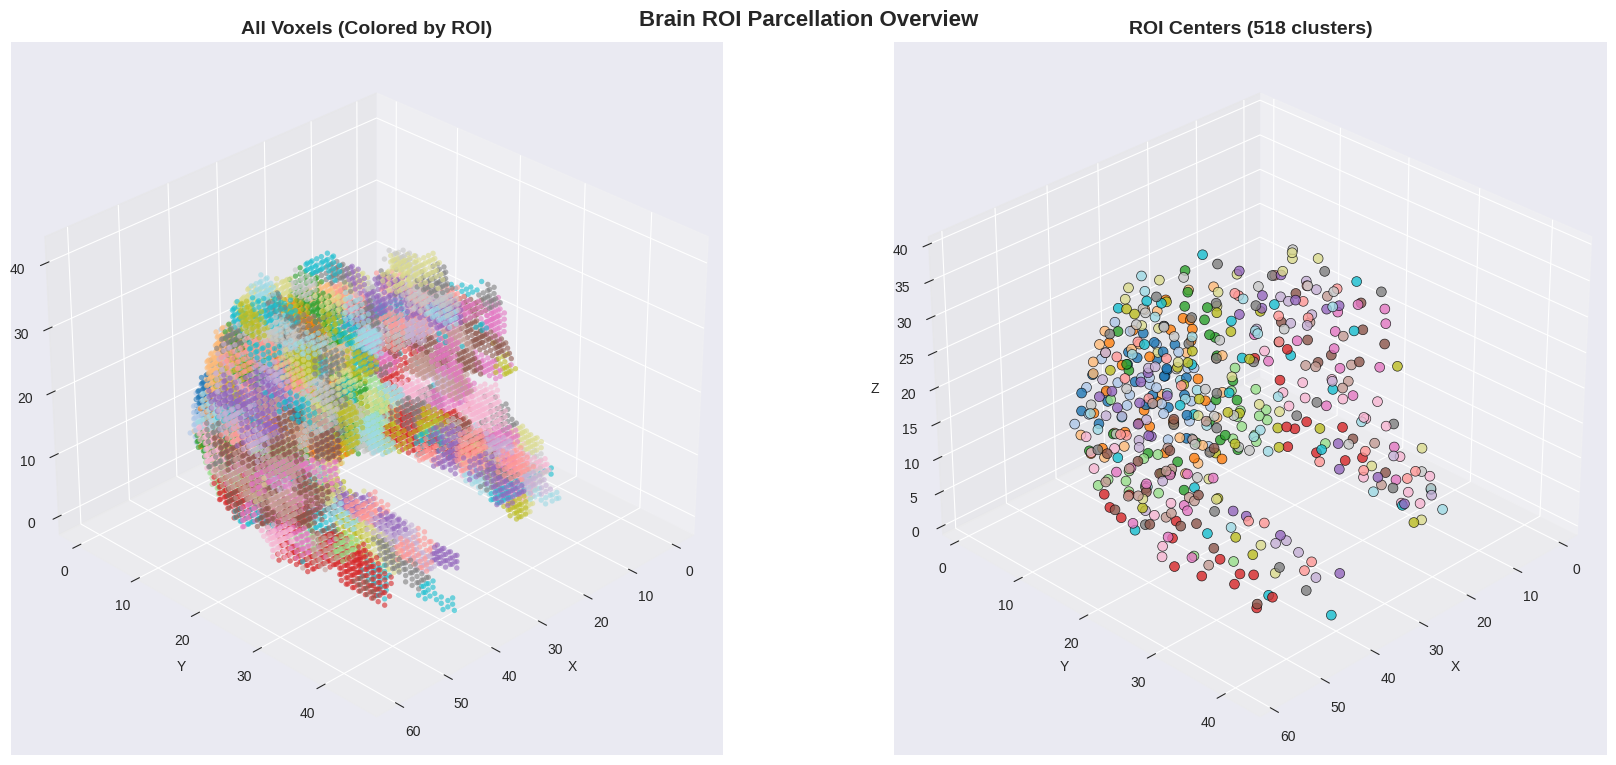

Total ROI clusters: 518
Total voxels: 15724
Voxels per cluster (avg): 30.4


In [8]:
# Visualize ROI regions in brain space
print("Visualizing ROI clusters in brain space...")

fig = plt.figure(figsize=(18, 8))

# All voxels colored by ROI
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(coords_3d[:, 0], coords_3d[:, 1], coords_3d[:, 2],
                      c=roi_labels, cmap='tab20', 
                      s=15, alpha=0.6, edgecolors='none')
ax1.set_title('All Voxels (Colored by ROI)', fontsize=14, fontweight='bold')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.view_init(elev=30, azim=45)

# ROI centers
roi_centers_vis = np.zeros((518, 3), dtype=np.float32)
for roi_idx in range(518):
    mask = (roi_labels == roi_idx)
    if mask.sum() > 0:
        roi_centers_vis[roi_idx] = coords_3d[mask].mean(axis=0)

ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(roi_centers_vis[:, 0], roi_centers_vis[:, 1], roi_centers_vis[:, 2],
                      c=np.arange(518), cmap='tab20',
                      s=50, alpha=0.8, 
                      edgecolors='black', linewidth=0.5)
ax2.set_title('ROI Centers (518 clusters)', fontsize=14, fontweight='bold')
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
ax2.view_init(elev=30, azim=45)

fig.suptitle('Brain ROI Parcellation Overview', fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

print(f"Total ROI clusters: {roi_labels.max() + 1}")
print(f"Total voxels: {len(coords_3d)}")
print(f"Voxels per cluster (avg): {len(coords_3d) / (roi_labels.max() + 1):.1f}")

Computing ROI centers from voxel coordinates...
ROI centers shape: (518, 3)


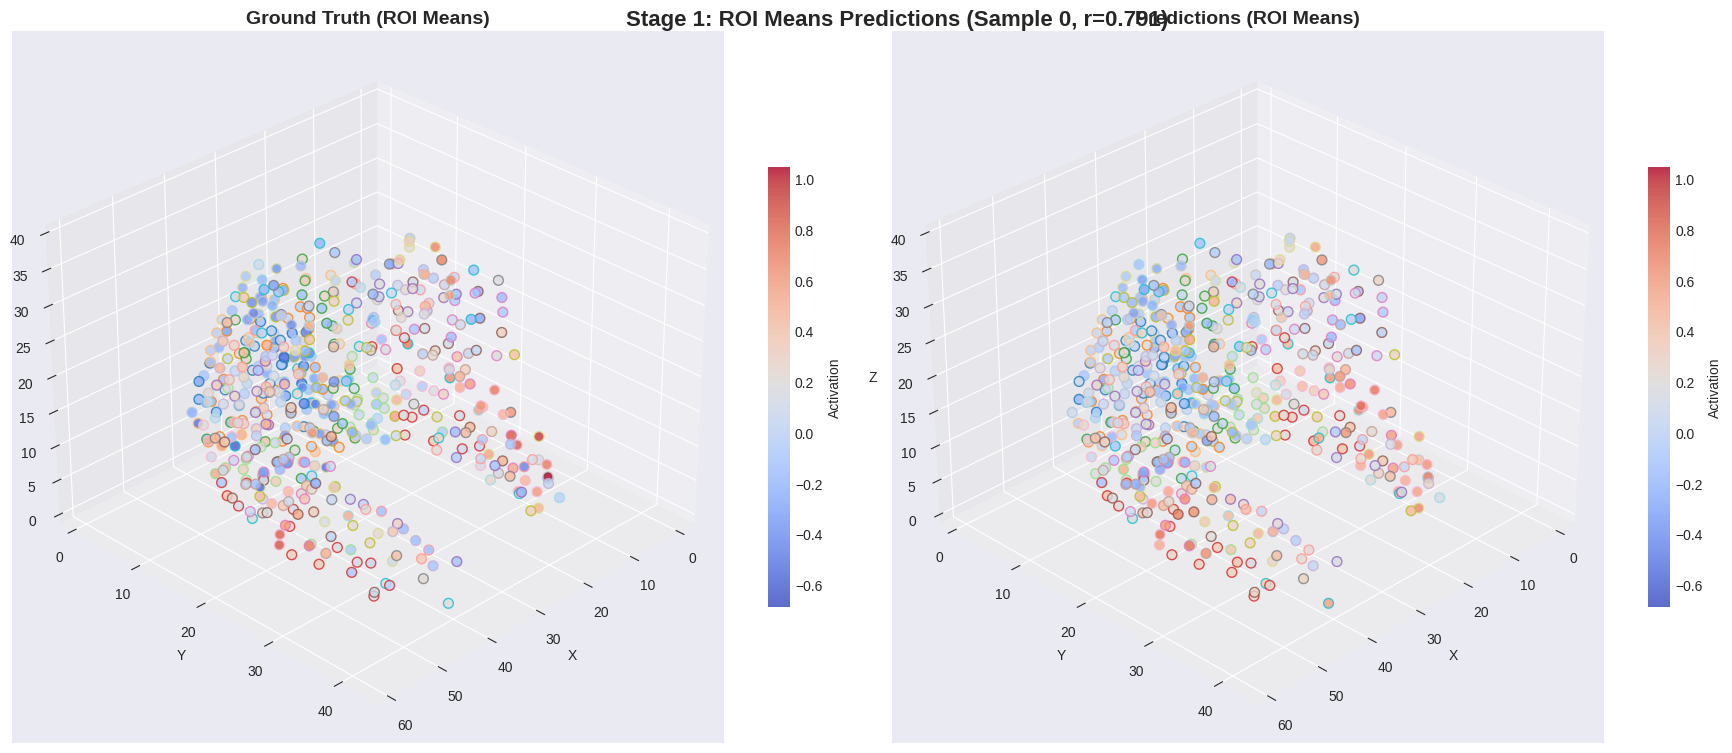

  Sample 0 - Correlation: 0.7906, MSE: 0.0313



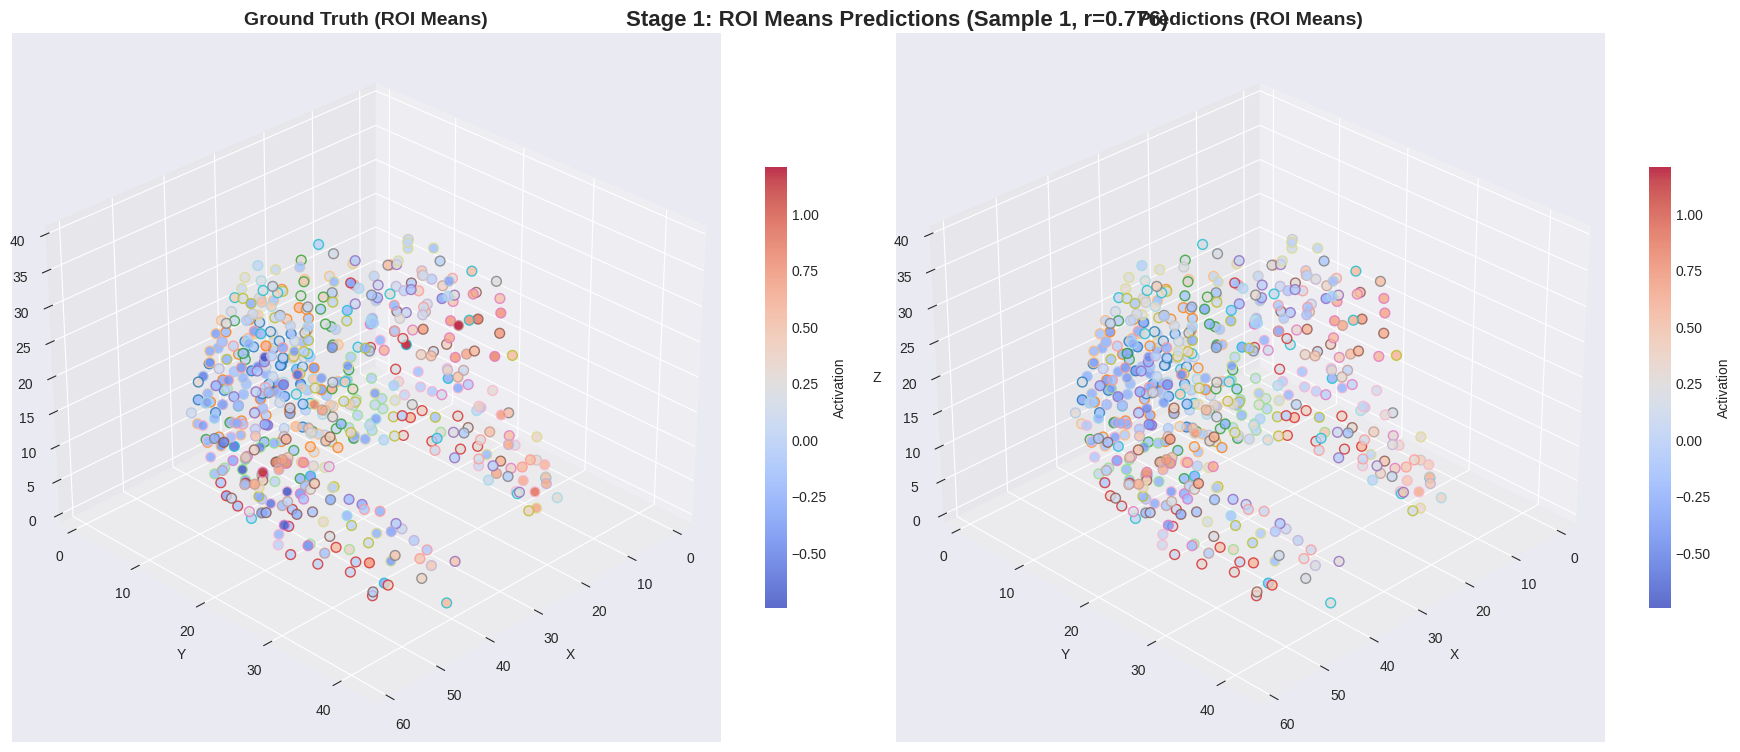

  Sample 1 - Correlation: 0.7762, MSE: 0.0418



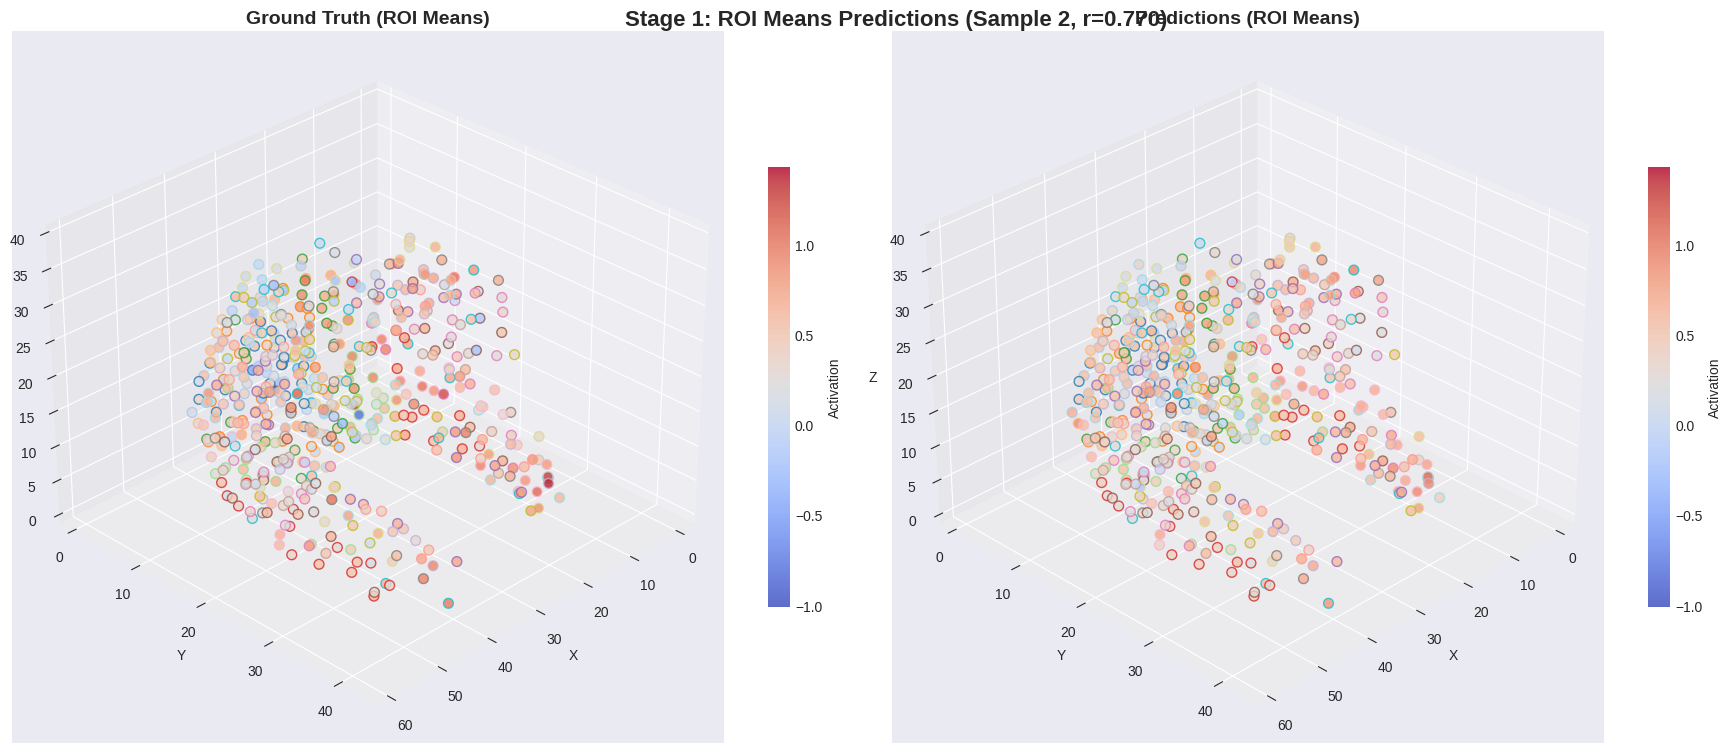

  Sample 2 - Correlation: 0.7702, MSE: 0.0370



In [9]:
# Stage 1 Visualization: ROI-level predictions

# Compute ROI centers from voxel coordinates
print("Computing ROI centers from voxel coordinates...")
roi_centers = np.zeros((518, 3), dtype=np.float32)
for roi_idx in range(518):
    mask = (roi_labels == roi_idx)
    if mask.sum() > 0:
        roi_centers[roi_idx] = coords_3d[mask].mean(axis=0)

print(f"ROI centers shape: {roi_centers.shape}")

# Visualize multiple samples
for sample_idx in range(min(3, len(predictions['embeddings']))):
    gt_roi = predictions['gt_roi_means'][sample_idx].numpy()
    pred_roi = predictions['pred_roi_means'][sample_idx].numpy()
    
    # Plot with ROI-colored borders
    fig = plot_roi_centers_with_labels(
        roi_centers, 
        gt_roi, 
        pred_roi,
        roi_labels=np.arange(518),
        title='Stage 1: ROI Means Predictions',
        sample_idx=sample_idx,
        view_init=(30, 45)  # Viewing angle
    )
    plt.show()
    
    # Per-sample metrics
    corr = np.corrcoef(gt_roi, pred_roi)[0, 1]
    mse = np.mean((gt_roi - pred_roi) ** 2)
    print(f"  Sample {sample_idx} - Correlation: {corr:.4f}, MSE: {mse:.4f}")
    print()

In [9]:
# Empty cell - combined into cell 13

## 6. Stage 2 Visualization - Full Voxels (15724 voxels)

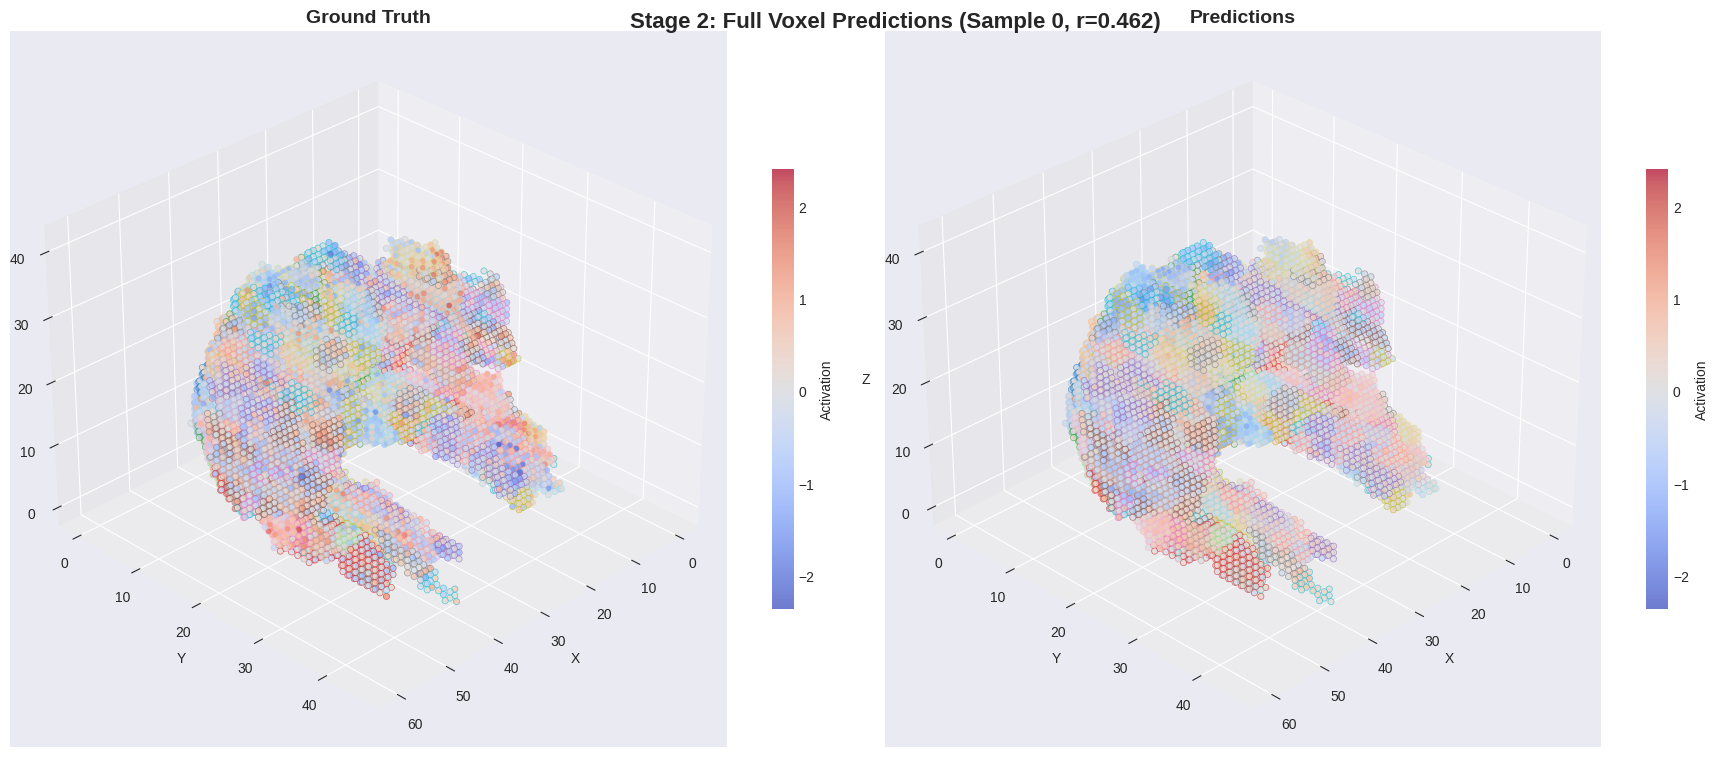

  Sample 0 - Correlation: 0.4621, MSE: 0.2653



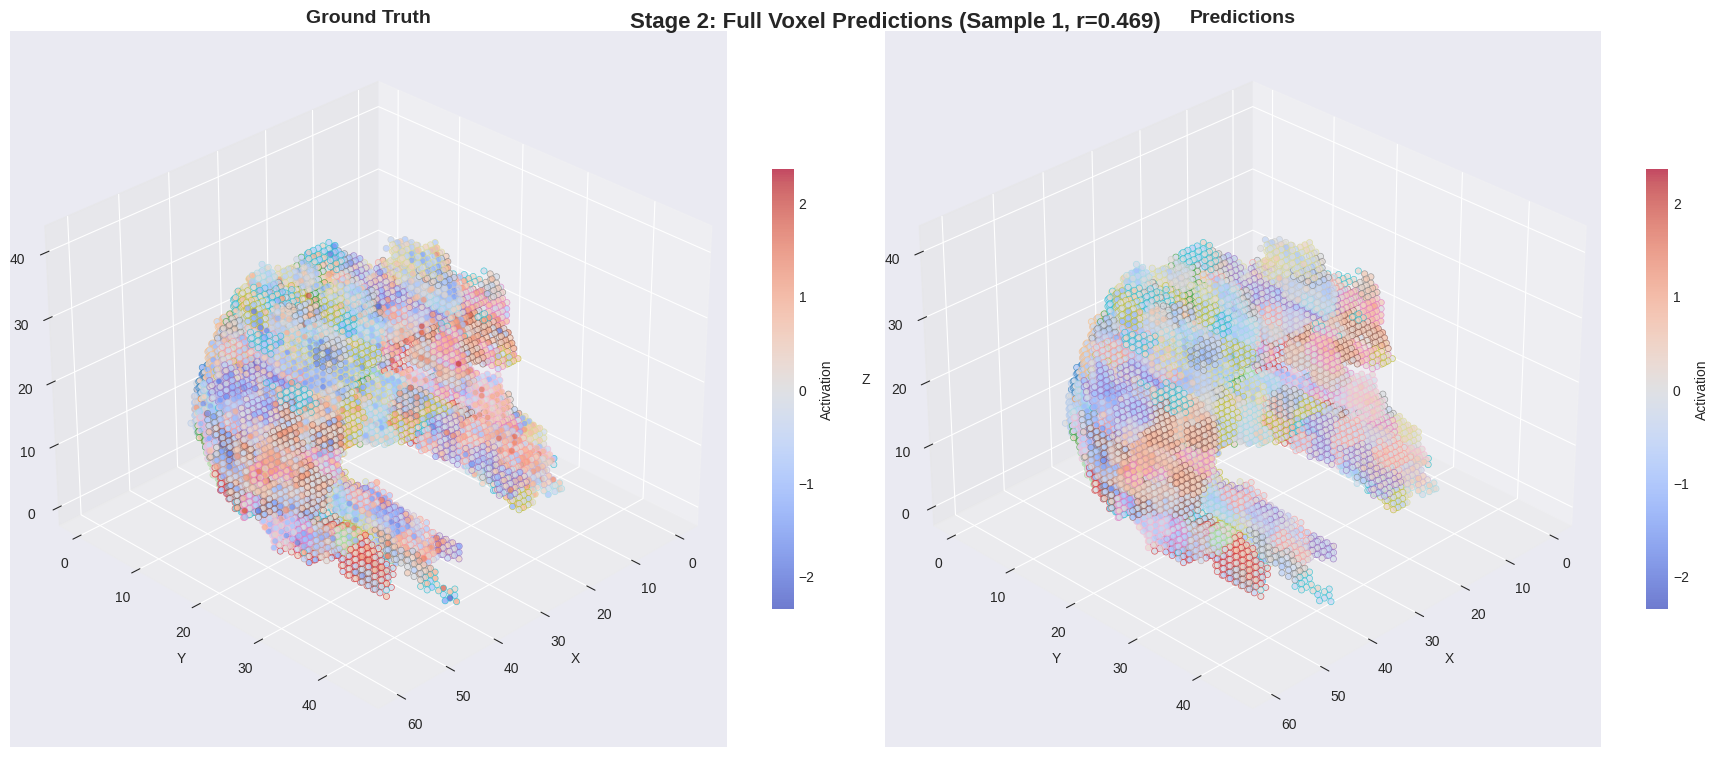

  Sample 1 - Correlation: 0.4688, MSE: 0.3344



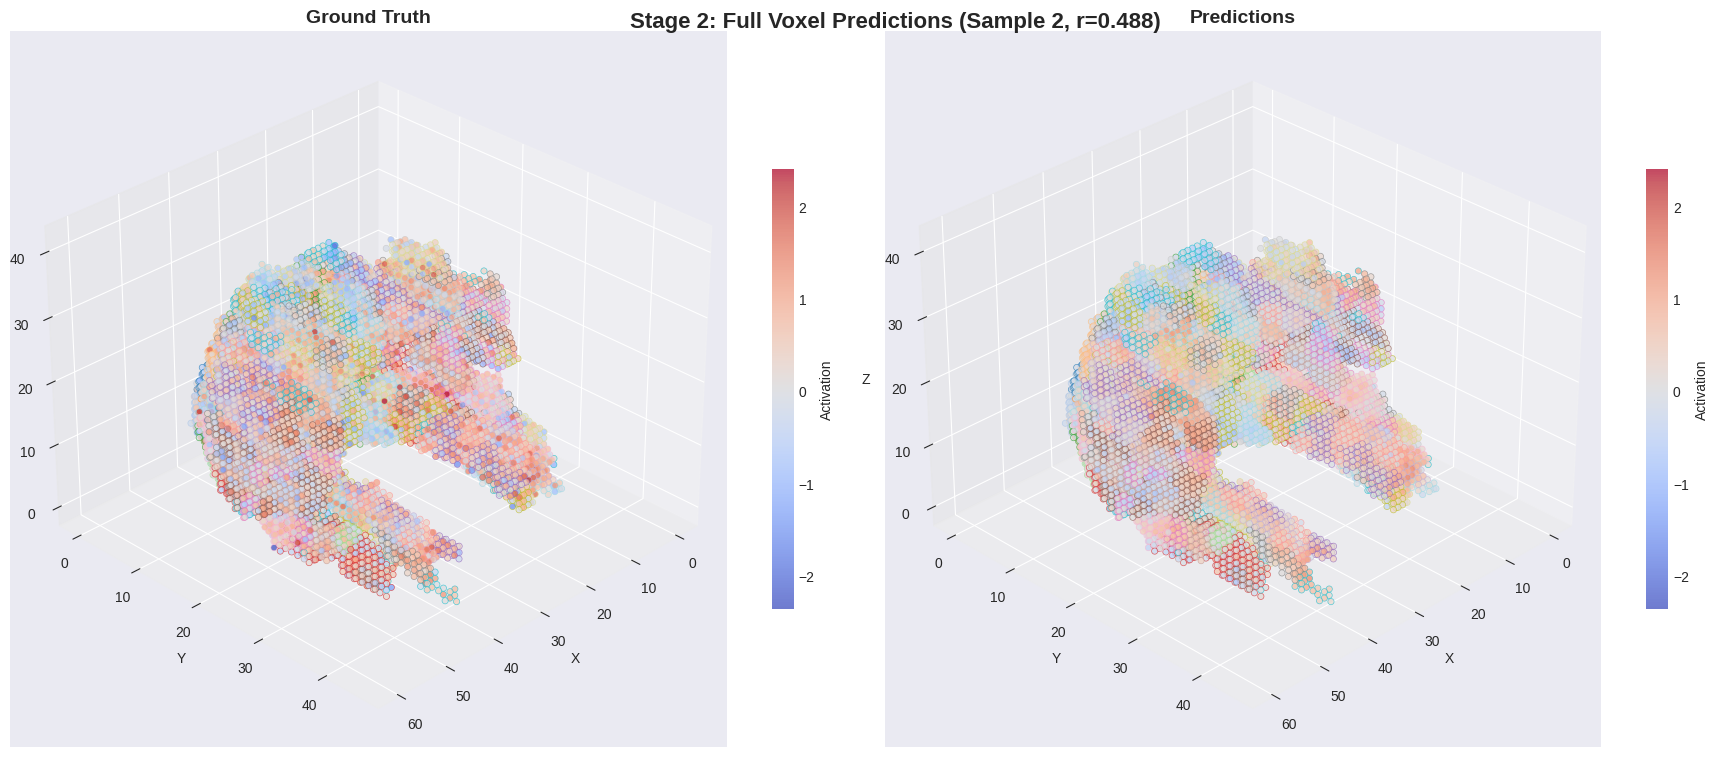

  Sample 2 - Correlation: 0.4876, MSE: 0.3073



In [10]:
# Stage 2 Visualization: Full voxel predictions

# Visualize multiple samples
for sample_idx in range(min(3, len(predictions['embeddings']))):
    gt_voxels = predictions['gt_voxels'][sample_idx].numpy()
    pred_voxels = predictions['pred_voxels'][sample_idx].numpy()
    
    # Plot with ROI-colored borders
    fig = plot_brain_predictions_with_roi(
        coords_3d, 
        gt_voxels, 
        pred_voxels,
        roi_labels,
        title='Stage 2: Full Voxel Predictions',
        sample_idx=sample_idx,
        view_init=(30, 45)  # Viewing angle
    )
    plt.show()
    
    # Per-sample metrics
    corr = np.corrcoef(gt_voxels, pred_voxels)[0, 1]
    mse = np.mean((gt_voxels - pred_voxels) ** 2)
    print(f"  Sample {sample_idx} - Correlation: {corr:.4f}, MSE: {mse:.4f}")
    print()

In [11]:
# Empty cell - combined into cell 16

In [11]:
# ============================================================================
# Pycortex Visualization Setup
# ============================================================================
print("Setting up Pycortex for cortical surface visualization...")

try:
    import cortex
    import nibabel as nib
    HAS_PYCORTEX = True
    print("✓ Pycortex imported successfully")
except ImportError:
    print("⚠️  Pycortex not installed. Installing...")
    import subprocess
    subprocess.run(["pip", "install", "pycortex"], check=True)
    import cortex
    import nibabel as nib
    HAS_PYCORTEX = True
    print("✓ Pycortex installed and imported")

# Subject info
SUBJECT_ID = "subj01"

# Check if subject exists in Pycortex database
available_subjects = list(cortex.db.subjects.keys()) if hasattr(cortex.db.subjects, 'keys') else []
print(f"\nAvailable subjects in Pycortex DB: {available_subjects}")

if SUBJECT_ID in available_subjects:
    print(f"✓ {SUBJECT_ID} ready in Pycortex database")
    print(f"✓ Transform 'func1pt8mm' configured")
else:
    print(f"⚠️  {SUBJECT_ID} not found in database")
    print("Note: Subject should be imported during notebook execution")

print("\nPycortex setup complete!")

Setting up Pycortex for cortical surface visualization...
✓ Pycortex imported successfully

Available subjects in Pycortex DB: ['colormaps', 'subj01']
✓ subj01 ready in Pycortex database
✓ Transform 'func1pt8mm' configured

Pycortex setup complete!


Visualizing prediction errors for Stage 2...


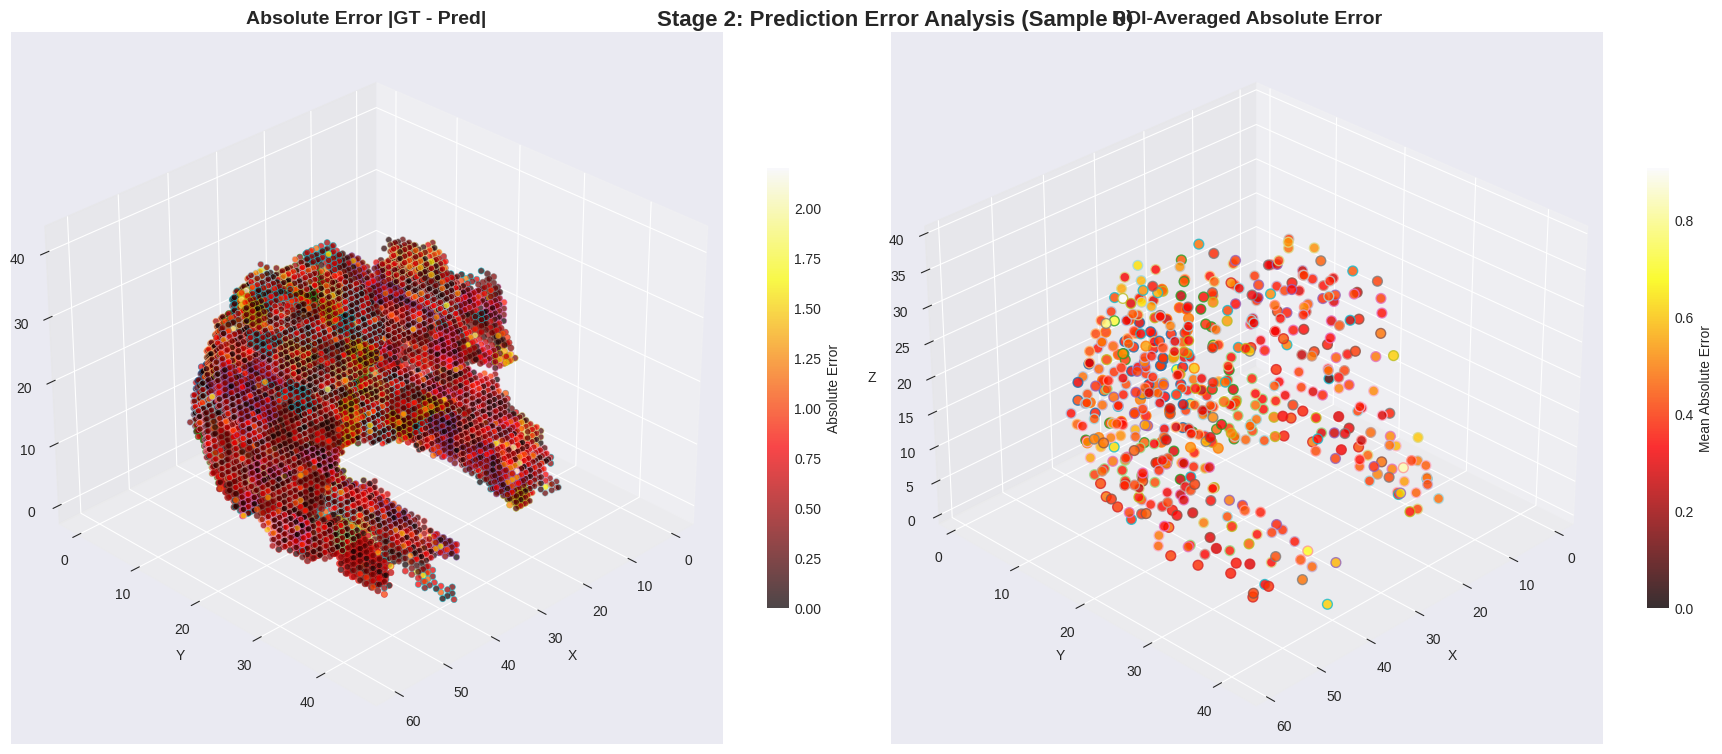


Error statistics:
  Mean absolute error: 0.4074
  Std error: 0.3151
  Max error: 2.2038
  Top 5 worst ROIs (by mean error):
    1. ROI 431: 0.9096
    2. ROI 183: 0.8376
    3. ROI 380: 0.7919
    4. ROI 482: 0.7578
    5. ROI 122: 0.7260


In [12]:
# Additional visualization: Absolute error map with ROI coloring
print("Visualizing prediction errors for Stage 2...")

sample_idx = 0
gt_voxels = predictions['gt_voxels'][sample_idx].numpy()
pred_voxels = predictions['pred_voxels'][sample_idx].numpy()
abs_error = np.abs(gt_voxels - pred_voxels)

fig = plt.figure(figsize=(18, 8))

# Absolute Error Map
ax1 = fig.add_subplot(121, projection='3d')
scatter1 = ax1.scatter(coords_3d[:, 0], coords_3d[:, 1], coords_3d[:, 2],
                      c=abs_error, cmap='hot', vmin=0, vmax=abs_error.max(),
                      s=20, alpha=0.7,
                      edgecolors=plt.cm.tab20(roi_labels / roi_labels.max()),
                      linewidth=0.5)
ax1.set_title('Absolute Error |GT - Pred|', fontsize=14, fontweight='bold')
ax1.set_xlabel('X'); ax1.set_ylabel('Y'); ax1.set_zlabel('Z')
ax1.view_init(elev=30, azim=45)
plt.colorbar(scatter1, ax=ax1, shrink=0.6, label='Absolute Error')

# ROI-averaged Error
roi_errors = np.zeros(518, dtype=np.float32)
for roi_idx in range(518):
    mask = (roi_labels == roi_idx)
    if mask.sum() > 0:
        roi_errors[roi_idx] = abs_error[mask].mean()

ax2 = fig.add_subplot(122, projection='3d')
scatter2 = ax2.scatter(roi_centers[:, 0], roi_centers[:, 1], roi_centers[:, 2],
                      c=roi_errors, cmap='hot', vmin=0, vmax=roi_errors.max(),
                      s=50, alpha=0.8,
                      edgecolors=plt.cm.tab20(np.arange(518) / 518),
                      linewidth=1)
ax2.set_title('ROI-Averaged Absolute Error', fontsize=14, fontweight='bold')
ax2.set_xlabel('X'); ax2.set_ylabel('Y'); ax2.set_zlabel('Z')
ax2.view_init(elev=30, azim=45)
plt.colorbar(scatter2, ax=ax2, shrink=0.6, label='Mean Absolute Error')

fig.suptitle(f'Stage 2: Prediction Error Analysis (Sample {sample_idx})', 
             fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

print(f"\nError statistics:")
print(f"  Mean absolute error: {abs_error.mean():.4f}")
print(f"  Std error: {abs_error.std():.4f}")
print(f"  Max error: {abs_error.max():.4f}")
print(f"  Top 5 worst ROIs (by mean error):")
worst_rois = np.argsort(roi_errors)[-5:][::-1]
for i, roi_idx in enumerate(worst_rois):
    print(f"    {i+1}. ROI {roi_idx}: {roi_errors[roi_idx]:.4f}")